<a href="https://colab.research.google.com/github/Developer-Abnam/100-Days-Of-ML-Code/blob/master/Linear_Regression_and_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv('/content/Concrete_Data.csv')
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
inputs = data.iloc[:, :-1].values
targets = data.iloc[:, -1].values.reshape(-1,1)

In [9]:
scaler = StandardScaler()
input_scaled = scaler.fit_transform(inputs)

In [10]:
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
target_tensor = torch.tensor(targets, dtype=torch.float32)

In [11]:
torch.manual_seed(42)
num_samples = input_tensor.shape[0]
indices = torch.randperm(num_samples)
split_idx = int(num_samples * 0.8)

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = input_tensor[train_indices]
y_train = target_tensor[train_indices]
X_test = input_tensor[test_indices]
y_test = target_tensor[test_indices]

In [15]:
num_features = X_train.shape[1]
W = torch.randn((num_features, 1), requires_grad=True)
W.data *= 0.01
b = torch.zeros((1,), requires_grad=True)

In [16]:
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Weight shape:", W.shape)
print("Bias shape:", b.shape)

Training set size: 824
Test set size: 206
Weight shape: torch.Size([8, 1])
Bias shape: torch.Size([1])


In [20]:
def predict(X):
  return torch.matmul(X, W) + b

In [18]:
def mse_loss(predictions, target):
  return torch.mean((predictions - target) ** 2)

In [25]:
learning_rates = 0.001
epochs = 100

for epoch in range(epochs):
  y_pred = predict(X_train)
  loss = mse_loss(y_pred, y_train)

  loss.backward()

  with torch.no_grad():
    W -= learning_rates * W.grad
    b -= learning_rates * b.grad

  W.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}: Loss {loss.item():.4f}")

Epoch 10: Loss 980.0752
Epoch 20: Loss 945.6935
Epoch 30: Loss 912.6868
Epoch 40: Loss 880.9993
Epoch 50: Loss 850.5778
Epoch 60: Loss 821.3713
Epoch 70: Loss 793.3309
Epoch 80: Loss 766.4095
Epoch 90: Loss 740.5622
Epoch 100: Loss 715.7455


Epoch 10: Loss 691.9182
Epoch 20: Loss 669.0403
Epoch 30: Loss 647.0740
Epoch 40: Loss 625.9822
Epoch 50: Loss 605.7299
Epoch 60: Loss 586.2836
Epoch 70: Loss 567.6107
Epoch 80: Loss 549.6802
Epoch 90: Loss 532.4624
Epoch 100: Loss 515.9286
Epoch 110: Loss 500.0515
Epoch 120: Loss 484.8047
Epoch 130: Loss 470.1629
Epoch 140: Loss 456.1021
Epoch 150: Loss 442.5989
Epoch 160: Loss 429.6309
Epoch 170: Loss 417.1767
Epoch 180: Loss 405.2159
Epoch 190: Loss 393.7286
Epoch 200: Loss 382.6960
Epoch 210: Loss 372.0998
Epoch 220: Loss 361.9227
Epoch 230: Loss 352.1479
Epoch 240: Loss 342.7592
Epoch 250: Loss 333.7415
Epoch 260: Loss 325.0799
Epoch 270: Loss 316.7601
Epoch 280: Loss 308.7684
Epoch 290: Loss 301.0920
Epoch 300: Loss 293.7179
Epoch 310: Loss 286.6345
Epoch 320: Loss 279.8300
Epoch 330: Loss 273.2936
Epoch 340: Loss 267.0142
Epoch 350: Loss 260.9818
Epoch 360: Loss 255.1865
Epoch 370: Loss 249.6190
Epoch 380: Loss 244.2701
Epoch 390: Loss 239.1311
Epoch 400: Loss 234.1939
Epoch 410

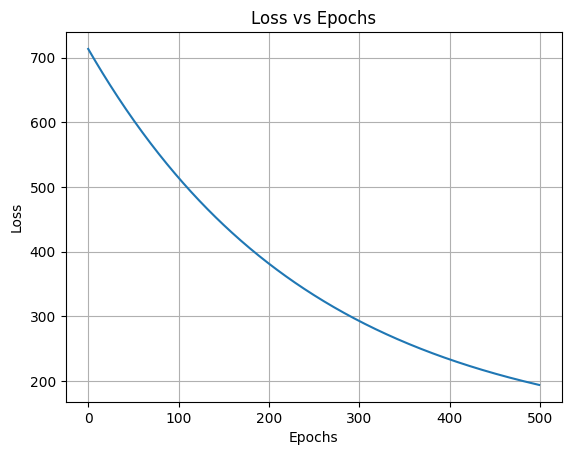

In [27]:
import matplotlib.pyplot as plt
learning_rates = 0.001
epochs = 500

losses = []
for epoch in range(epochs):
  y_pred = predict(X_train)
  loss = mse_loss(y_pred, y_train)
  losses.append(loss.item())

  loss.backward()
  with torch.no_grad():
    W -= learning_rates * W.grad
    b -= learning_rates * b.grad

  W.grad.zero_()
  b.grad.zero_()

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}: Loss {loss.item():.4f}")

plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.grid(True)
plt.show()

In [28]:
y_test_pred = predict(X_test)

test_loss = mse_loss(y_test_pred, y_test)
print(f"Test Loss: {test_loss.item():.4f}")

Test Loss: 191.4870


In [29]:
def mae_loss(prediction, target):
  error = torch.abs(prediction - target)
  return torch.mean(error)

In [30]:
test_loss_2 = mae_loss(y_test_pred, y_test)
print(f"Test Loss: {test_loss_2.item():.4f}")

Test Loss: 11.0726
